# Predikcija cene Airbnb oglasa u Njujorku (2024) — Regresija

**Dataset:** New York Airbnb Open Data 2024 — Kaggle, autor *vrindakallu*
(https://www.kaggle.com/datasets/vrindakallu/new-york-dataset)

**Tip problema:** Regresija (nadgledano učenje)

**Cilj:** Izgraditi model koji na osnovu karakteristika oglasa (lokacija, tip smeštaja,
kapacitet, istorijat recenzija, dostupnost) predviđa cenu noćenja, i identifikovati koji
atributi najviše utiču na formiranje cene.

> **Napomena o polaznom kodu:** Na Kaggle stranici dataseta postoje javno dostupni notebook-ovi
> (uglavnom EDA i osnovna regresija). U tekstu rada eksplicitno navesti tačan notebook korišćen
> kao polazna osnova (ako je korišćen) i šta je konkretno unapređeno — u ovom radu: (1) poređenje
> dva algoritma (linearna regresija i Random Forest) sa unakrsnom validacijom, (2) rad na
> log-transformisanoj ciljnoj promenljivoj radi ublažavanja jake asimetrije cene, i (3) analiza
> važnosti atributa (feature importance) uz poslovnu interpretaciju.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("new_york_listings_2024.csv")
print("Dimenzije skupa podataka:", df.shape)
df.head()


Dimenzije skupa podataka: (20758, 22)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,2015-12-20,0.03,1,0,0,No License,5.0,1,1,Not specified
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,2023-05-01,0.24,139,364,2,No License,4.67,2,1,1
2,971353993633883038,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,2023-12-18,1.67,1,343,6,Exempt,4.17,1,2,1
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2023-09-17,1.38,2,363,12,No License,4.64,1,1,1
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133,335,3,No License,4.91,Studio,1,1


## 1. Istraživačka analiza podataka (EDA)

Skup podataka sadrži **20.758 oglasa** i 22 atributa. Cilj EDA faze je razumeti raspodelu cene
(ciljne promenljive), njenu vezu sa ostalim atributima i identifikovati anomalije koje mogu
ometati regresioni model.


In [2]:
df.info()
print()
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   name                            20758 non-null  object 
 2   host_id                         20758 non-null  int64  
 3   host_name                       20758 non-null  object 
 4   neighbourhood_group             20758 non-null  object 
 5   neighbourhood                   20758 non-null  object 
 6   latitude                        20758 non-null  float64
 7   longitude                       20758 non-null  float64
 8   room_type                       20758 non-null  object 
 9   price                           20758 non-null  float64
 10  minimum_nights                  20758 non-null  int64  
 11  number_of_reviews               20758 non-null  int64  
 12  last_review                     

### 1.1 Raspodela cene (ciljna promenljiva)

count     20758.000000
mean        187.776616
std        1022.797208
min          10.000000
25%          80.000000
50%         125.000000
75%         199.000000
max      100000.000000
Name: price, dtype: float64

Broj oglasa sa cenom > 1000$: 168
Broj oglasa sa cenom > 2000$: 51


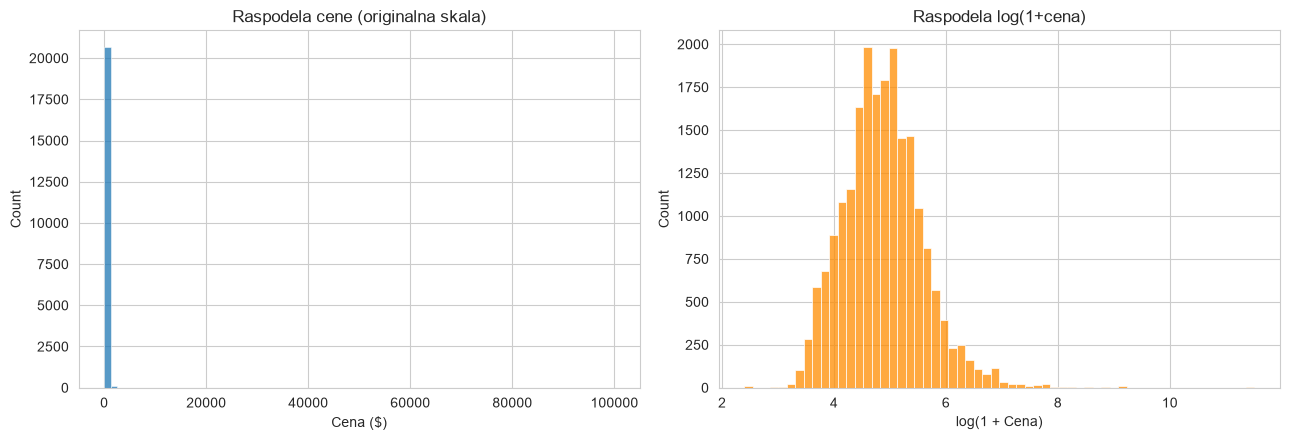

In [3]:
print(df['price'].describe())
print()
print("Broj oglasa sa cenom > 1000$:", (df['price'] > 1000).sum())
print("Broj oglasa sa cenom > 2000$:", (df['price'] > 2000).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['price'], bins=80, ax=axes[0])
axes[0].set_title("Raspodela cene (originalna skala)")
axes[0].set_xlabel("Cena ($)")

sns.histplot(np.log1p(df['price']), bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Raspodela log(1+cena)")
axes[1].set_xlabel("log(1 + Cena)")
plt.tight_layout()
plt.show()


**Komentar:** Cena je jako desno zakošena (prosek 187,78$, medijana 125$), sa ekstremnim
vrednostima do 100.000$ koje su najverovatnije greške u unosu ili namerno "blokirajuće" cene
(host postavi apsurdno visoku cenu da spreči rezervacije, a da ne mora da ugasi oglas). Ovakve
vrednosti bi enormno napuhale RMSE metriku i navele model da pokuša da "pogodi" par ekstremnih
slučajeva na štetu tačnosti za ostatak tržišta. Log-transformacija svodi raspodelu na približno
normalnu, što je mnogo pogodnije za regresione modele — ovo je razlog zašto će model kasnije
predviđati **log(cena)**, a ne sirovu cenu direktno.


### 1.2 Cena po tipu smeštaja i gradskoj oblasti

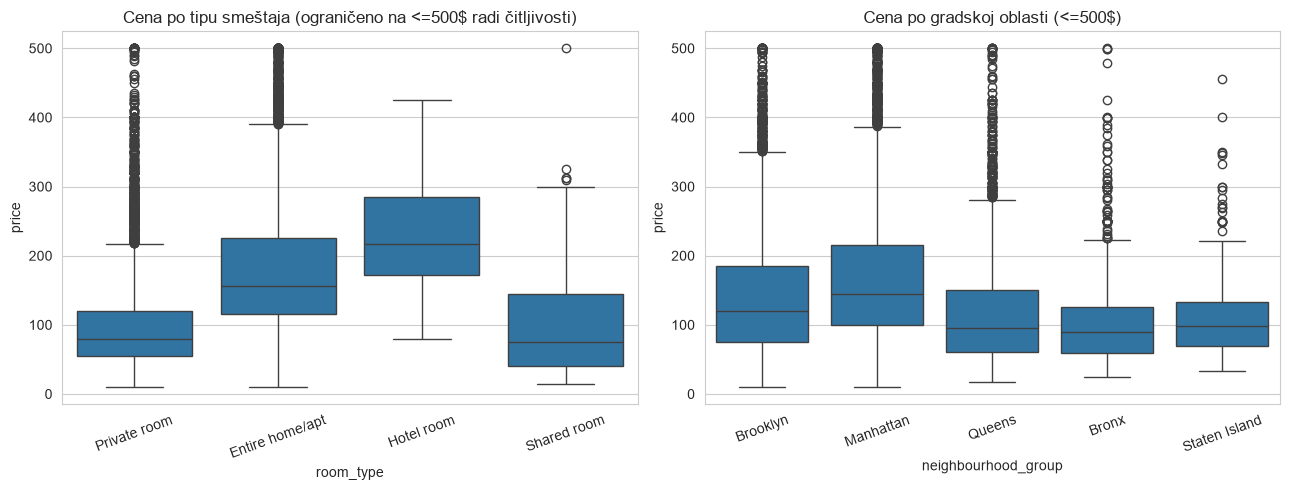

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df[df['price'] <= 500], x='room_type', y='price', ax=axes[0])
axes[0].set_title("Cena po tipu smeštaja (ograničeno na <=500$ radi čitljivosti)")
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df[df['price'] <= 500], x='neighbourhood_group', y='price', ax=axes[1])
axes[1].set_title("Cena po gradskoj oblasti (<=500$)")
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


**Komentar:** Manhattan ima vidno viši medijalni raspon cena od ostalih oblasti, a
"Entire home/apt" je dosledno skuplji od "Private room" i "Shared room" — ovo su očekivani, ali
bitni signali da su i lokacija i tip smeštaja informativni prediktori cene.


### 1.3 Korelacije sa cenom

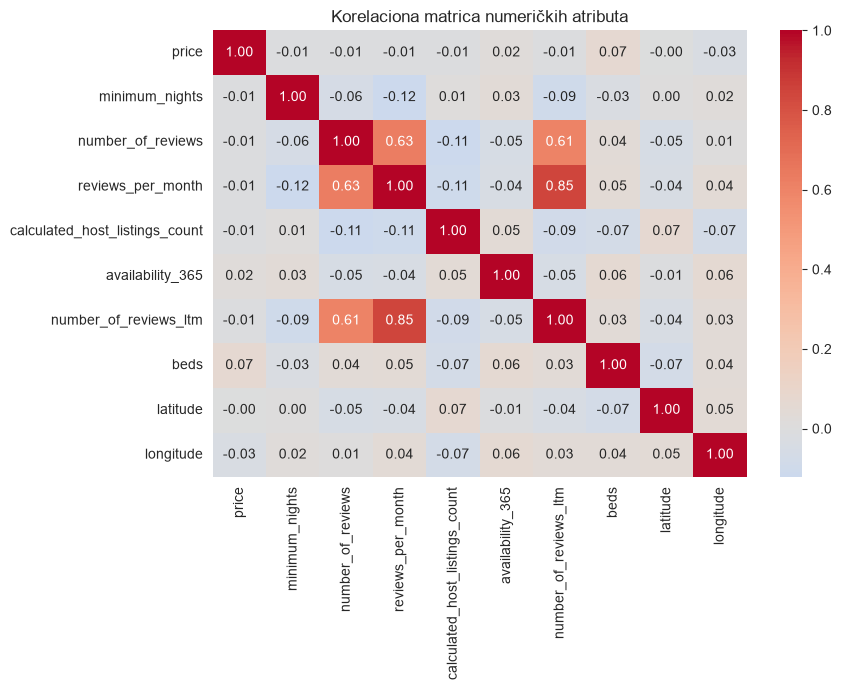

Korelacija atributa sa cenom (opadajuće po apsolutnoj vrednosti):
beds                              0.066882
longitude                        -0.033460
availability_365                  0.020151
number_of_reviews                -0.012588
number_of_reviews_ltm            -0.011263
reviews_per_month                -0.009917
calculated_host_listings_count   -0.007333
minimum_nights                   -0.006527
latitude                         -0.001143
Name: price, dtype: float64


In [5]:
num_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm',
            'beds', 'latitude', 'longitude']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelaciona matrica numeričkih atributa")
plt.tight_layout()
plt.show()

print("Korelacija atributa sa cenom (opadajuće po apsolutnoj vrednosti):")
print(corr['price'].drop('price').sort_values(key=abs, ascending=False))


**Komentar:** Nijedan pojedinačni numerički atribut nema jaku linearnu korelaciju sa cenom
(sve ispod 0,15 u apsolutnoj vrednosti) — što je signal da cena verovatno zavisi od **kombinacije**
atributa (posebno kategoričkih poput tipa smeštaja i lokacije) i da nelinearan model (Random
Forest) ima realne šanse da nadmaši prostu linearnu regresiju.


### 1.4 Anomalije i kvalitet podataka

In [6]:
rating_missing = df['rating'].str.strip().eq('No rating').sum()
baths_missing = df['baths'].eq('Not specified').sum()
print("`rating` = 'No rating':", rating_missing, f"({rating_missing/len(df)*100:.1f}%)")
print("`baths` = 'Not specified':", baths_missing)
print("`bedrooms` = 'Studio':", (df['bedrooms'] == 'Studio').sum())
print("Licenca - bez licence:", (df['license'] == 'No License').sum())


`rating` = 'No rating': 3593 (17.3%)
`baths` = 'Not specified': 13
`bedrooms` = 'Studio': 1815
Licenca - bez licence: 17569


**Komentar:** Isti problemi kvaliteta podataka kao i u OLAP delu rada — `rating`, `bedrooms`
i `baths` sadrže tekstualne oznake umesto brojeva/NULL vrednosti i moraju se ručno mapirati pre
modelovanja (sekcija 2).


## 2. Primenjena metoda i priprema podataka

**Odabrani tip problema: regresija.** Cilj je predikcija kontinuirane ciljne promenljive (cena)
na osnovu ostalih atributa oglasa — po definiciji regresioni problem, za razliku od klasifikacije
(diskretne klase) ili klasterovanja (bez ciljne promenljive).

### 2.1 Čišćenje podataka

- `rating`: "No rating" → NaN → imputacija medijanom
- `bedrooms`: "Studio" → 0
- `baths`: "Not specified" → NaN → imputacija medijanom
- `license`: pretvoreno u binarni atribut `has_license` (1 = ima bilo kakvu registraciju/izuzeće
  različito od "No License", 0 = nema)
- Uklonjeno 51 od 20.758 oglasa sa cenom > 2000$ (0,25% podataka) — ove ekstremne vrednosti su
  najverovatnije greške unosa ili namerno blokirajuće cene, ne reprezentuju stvarno tržište i
  njihovo zadržavanje bi nesrazmerno uticalo na RMSE metriku


In [7]:
df_model = df.copy()

df_model['rating_num'] = pd.to_numeric(df_model['rating'].str.strip(), errors='coerce')
df_model['bedrooms_num'] = pd.to_numeric(df_model['bedrooms'].replace('Studio', '0'),
                                          errors='coerce')
df_model['baths_num'] = pd.to_numeric(df_model['baths'].replace('Not specified', np.nan),
                                       errors='coerce')
df_model['rating_num'] = df_model['rating_num'].fillna(df_model['rating_num'].median())
df_model['baths_num'] = df_model['baths_num'].fillna(df_model['baths_num'].median())
df_model['has_license'] = (df_model['license'] != 'No License').astype(int)

before = len(df_model)
df_model = df_model[df_model['price'] <= 2000].copy()
print(f"Uklonjeno {before - len(df_model)} oglasa sa cenom > 2000$.")
print(f"Preostalo {len(df_model)} oglasa za modelovanje.")

df_model['log_price'] = np.log1p(df_model['price'])


Uklonjeno 51 oglasa sa cenom > 2000$.
Preostalo 20707 oglasa za modelovanje.


### 2.2 Kodiranje kategoričkih promenljivih

`room_type` i `neighbourhood_group` su kodirani **one-hot enkodiranjem** (`pd.get_dummies`,
uz `drop_first=True` da se izbegne multikolinearnost) — regresioni modeli ne mogu direktno da
rade sa tekstualnim kategorijama, a one-hot je standardan pristup za kategorije bez prirodnog
uređenja (nema smisla reći da je "Manhattan > Brooklyn" kao broj).

### 2.3 Izbor atributa i standardizacija

Numerički atributi: `minimum_nights, number_of_reviews, reviews_per_month,
calculated_host_listings_count, availability_365, number_of_reviews_ltm, rating_num,
bedrooms_num, baths_num, beds, latitude, longitude, has_license`, uz dummy kolone za
`room_type` i `neighbourhood_group`.

Standardizacija (`StandardScaler`) je primenjena **samo za linearnu regresiju** — koeficijenti
linearnog modela su osetljivi na skalu ulaznih atributa. Random Forest je neosetljiv na skalu
(zasnovan je na pragovima/splitovima, ne na rastojanju), pa se za njega koriste originalne,
neskalirane vrednosti.


In [8]:
cat_cols = ['room_type', 'neighbourhood_group']
df_enc = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

num_features = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
                 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm',
                 'rating_num', 'bedrooms_num', 'baths_num', 'beds', 'latitude', 'longitude',
                 'has_license']
dummy_cols = [c for c in df_enc.columns if c.startswith('room_type_')
              or c.startswith('neighbourhood_group_')]
feature_cols = num_features + dummy_cols

X = df_enc[feature_cols]
y = df_enc['log_price']

print("Broj atributa posle enkodiranja:", len(feature_cols))
print(feature_cols)


Broj atributa posle enkodiranja: 20
['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'rating_num', 'bedrooms_num', 'baths_num', 'beds', 'latitude', 'longitude', 'has_license', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island']


## 3. Trening i validacija modela

### 3.1 Podela na trening i test skup

Podaci su podeljeni na **80% trening / 20% test** (`train_test_split`, `random_state=42` radi
ponovljivosti). Test skup se ne koristi ni za treniranje ni za izbor hiperparametara — služi
isključivo za finalnu, nepristrasnu procenu performansi.

### 3.2 Unakrsna validacija (Cross-Validation)

Na trening skupu je primenjena **5-struka unakrsna validacija (5-fold CV)**: trening skup se
podeli na 5 delova, model se trenira na 4 dela i testira na petom, ponavlja se 5 puta tako da
svaki deo jednom bude test. Ovo daje robusniju procenu performansi modela (i njenu varijansu)
nego jedna jedina podela, i pomaže da se proveri da li je rezultat na test skupu bio "srećan"
slučaj ili se model zaista stabilno ponaša.

Balansiranje klasa nije primenjeno jer je u pitanju regresija, ne klasifikacija — koncept
balansiranja klasa se odnosi na diskretne kategorije.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Trening skup:", X_train.shape, " Test skup:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lin_reg = LinearRegression()
cv_scores_lin = cross_val_score(lin_reg, X_train_scaled, y_train, cv=kf, scoring='r2')
print(f"Linear Regression - 5-fold CV R^2: {cv_scores_lin.mean():.4f} (+/- {cv_scores_lin.std():.4f})")

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
cv_scores_rf = cross_val_score(rf_reg, X_train, y_train, cv=kf, scoring='r2')
print(f"Random Forest    - 5-fold CV R^2: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")


Trening skup: (16565, 20)  Test skup: (4142, 20)
Linear Regression - 5-fold CV R^2: 0.4702 (+/- 0.0071)
Random Forest    - 5-fold CV R^2: 0.6325 (+/- 0.0059)


**Komentar:** Mala standardna devijacija (ispod 0,01) kod oba modela pokazuje da je
performansa stabilna kroz različite podele podataka, ne slučajan artefakt jedne konkretne
podele. Random Forest već u CV fazi jasno nadmašuje linearnu regresiju.


## 4. Evaluacija modela

Konačni modeli (trenirani na celom trening skupu) se evaluiraju na **test skupu** koji nijedan
model nije video tokom treniranja. Koriste se standardne regresione metrike:

- **RMSE** (Root Mean Squared Error) — koren srednje kvadratne greške, u istim jedinicama kao
  ciljna promenljiva; više kažnjava velike greške
- **MAE** (Mean Absolute Error) — prosečna apsolutna greška, lakša za intuitivno tumačenje
- **R²** — udeo varijanse cene koji model objašnjava (1 = savršen model, 0 = model nije bolji od
  proseka)

Metrike se prikazuju i na log-skali (na kojoj je model treniran) i vraćene na originalnu
dolarsku skalu (`expm1`) radi lakšeg tumačenja.


In [10]:
results = []

# Linear Regression
lin_reg.fit(X_train_scaled, y_train)
pred_log_lin = lin_reg.predict(X_test_scaled)
pred_price_lin = np.expm1(pred_log_lin)

# Random Forest
rf_reg.fit(X_train, y_train)
pred_log_rf = rf_reg.predict(X_test)
pred_price_rf = np.expm1(pred_log_rf)

true_price = np.expm1(y_test)

for name, pred_log, pred_price in [('Linear Regression', pred_log_lin, pred_price_lin),
                                     ('Random Forest', pred_log_rf, pred_price_rf)]:
    r2 = r2_score(y_test, pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
    mae_log = mean_absolute_error(y_test, pred_log)
    rmse_price = np.sqrt(mean_squared_error(true_price, pred_price))
    mae_price = mean_absolute_error(true_price, pred_price)
    results.append({'Model': name, 'R2 (log)': round(r2, 4),
                     'RMSE (log)': round(rmse_log, 4), 'MAE (log)': round(mae_log, 4),
                     'RMSE ($)': round(rmse_price, 2), 'MAE ($)': round(mae_price, 2)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


            Model  R2 (log)  RMSE (log)  MAE (log)  RMSE ($)  MAE ($)
Linear Regression    0.4754      0.5034     0.3893    262.72    70.41
    Random Forest    0.6397      0.4172     0.3098    118.21    56.25


**Interpretacija:** Random Forest objašnjava **64%** varijanse log-cene (R²=0,64) naspram
**48%** kod linearne regresije (R²=0,48) — znatna razlika. U dolarskom iznosu, prosečna apsolutna
greška (MAE) Random Forest modela je **≈56$**, naspram **≈70$** kod linearne regresije. Imajući u
vidu da je medijalna cena oglasa 125$, greška od 56$ je i dalje značajna u relativnom smislu —
model uhvati opšti obrazac formiranja cene, ali ne i sve specifičnosti pojedinačnog oglasa (npr.
kvalitet enterijera, fotografije, reputaciju hosta van brojčane ocene — atributi koji nisu ni
dostupni u datasetu).


## 5. Poređenje algoritama

| Model | R² (log skala) | RMSE ($) | MAE ($) | Karakter modela |
|---|---|---|---|---|
| Linear Regression | 0,48 | ≈263 | ≈70 | Linearan, lako interpretabilan, ali ne hvata interakcije između atributa |
| Random Forest | 0,64 | ≈118 | ≈56 | Nelinearan, hvata interakcije (npr. "Manhattan + Entire home" efekat), manje direktno interpretabilan |

**Zašto Random Forest daje bolje rezultate u ovom kontekstu:** Cena Airbnb oglasa ne zavisi od
atributa na strogo aditivan/linearan način — npr. efekat tipa smeštaja na cenu verovatno **zavisi
od lokacije** (Entire home/apt je mnogo skuplji specifično na Manhattanu nego u Bronxu, a to je
interakcijski, ne aditivni efekat). Linearna regresija po definiciji ne može da uhvati takve
interakcije bez ručnog inženjeringa dodatnih atributa (npr. proizvoda dve kolone), dok Random
Forest to radi prirodno kroz svoju stablo-baziranu strukturu. Cena ovoga je gubitak direktne
interpretabilnosti pojedinačnih koeficijenata — kompenzovano feature importance analizom
(sekcija 6).


## 6. Vizualizacija rezultata

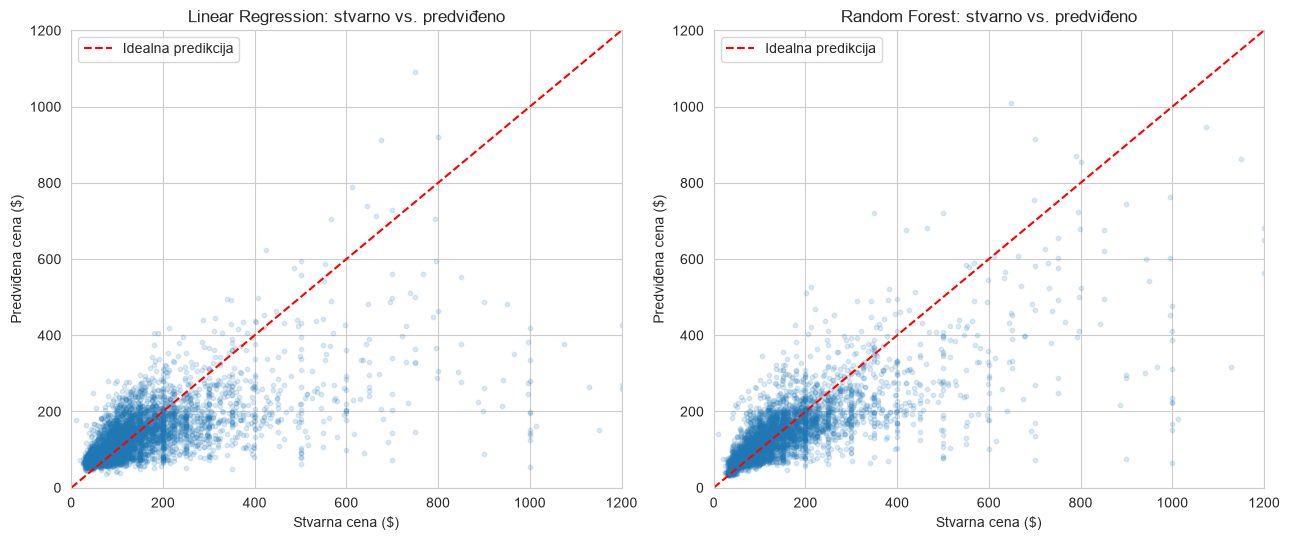

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, pred, name in zip(axes, [pred_price_lin, pred_price_rf],
                            ['Linear Regression', 'Random Forest']):
    ax.scatter(true_price, pred, alpha=0.15, s=10)
    max_val = min(true_price.max(), 1200)
    ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Idealna predikcija')
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel("Stvarna cena ($)")
    ax.set_ylabel("Predviđena cena ($)")
    ax.set_title(f"{name}: stvarno vs. predviđeno")
    ax.legend()

plt.tight_layout()
plt.show()


**Komentar:** Tačke bliže crvenoj isprekidanoj liniji predstavljaju tačnije predikcije. Kod
Random Forest modela (desno) tačke su vidljivo zbijenije oko linije, posebno u opsegu do 400$ gde
se nalazi većina tržišta. Oba modela pokazuju sistematsku grešku kod vrlo visokih cena (iznad
600-700$) — model teži da **potceni** ekstremno skupe oglase, jer ih ima malo u trening skupu pa
model "ne uči" dovoljno o tom segmentu (klasičan problem nedovoljne zastupljenosti ekstremnih
vrednosti).


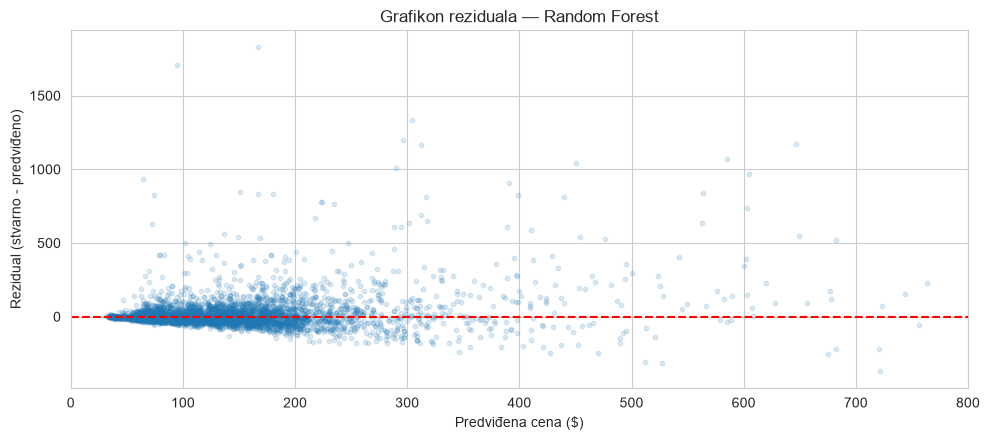

In [12]:
residuals_rf = true_price - pred_price_rf

plt.figure(figsize=(10, 4.5))
plt.scatter(pred_price_rf, residuals_rf, alpha=0.15, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlim(0, 800)
plt.xlabel("Predviđena cena ($)")
plt.ylabel("Rezidual (stvarno - predviđeno)")
plt.title("Grafikon reziduala — Random Forest")
plt.tight_layout()
plt.show()


**Komentar:** Rezidualni grafikon pokazuje blagi **heteroskedastičan** obrazac — varijansa
greške raste sa cenom (tačke se šire ka desnoj strani grafikona). Ovo je uobičajeno kod modela
cena i dodatno opravdava rad na log-transformisanoj ciljnoj promenljivoj, koja ublažava (ali ne
uklanja potpuno) ovaj efekat.


### Važnost atributa (Feature Importance) — Random Forest

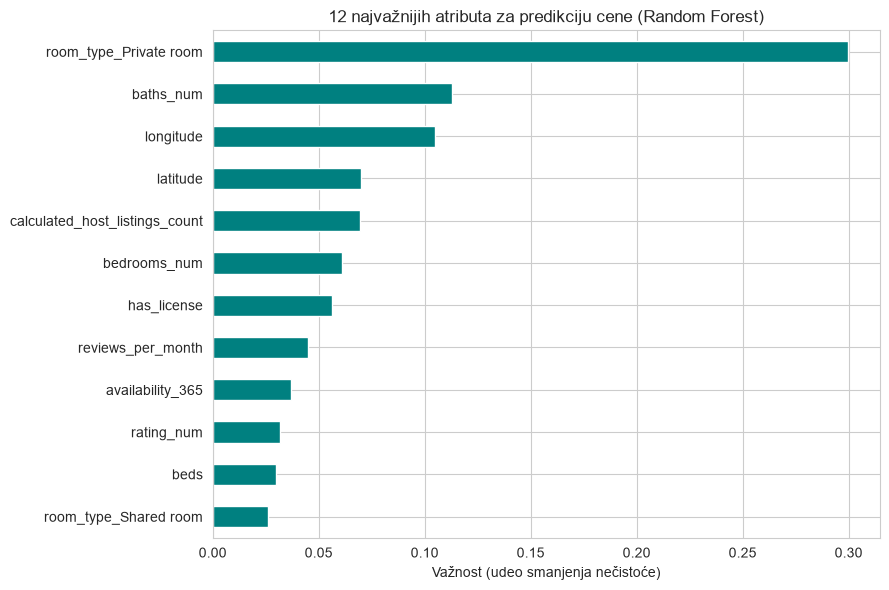

room_type_Private room            0.299799
baths_num                         0.112741
longitude                         0.105018
latitude                          0.069998
calculated_host_listings_count    0.069628
bedrooms_num                      0.060876
has_license                       0.056428
reviews_per_month                 0.044953
availability_365                  0.037122
rating_num                        0.031876
dtype: float64


In [13]:
importances = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.head(12).sort_values().plot(kind='barh', color='teal')
plt.title("12 najvažnijih atributa za predikciju cene (Random Forest)")
plt.xlabel("Važnost (udeo smanjenja nečistoće)")
plt.tight_layout()
plt.show()

print(importances.head(10))


**Komentar:** `room_type_Private room` je ubedljivo najvažniji pojedinačni atribut (≈30%) —
logično, tip smeštaja je fundamentalna odrednica cene. Sledi `baths_num` i geografske koordinate
(`longitude`, `latitude`) — bitno je da koordinate nose više informacije o ceni nego kategorička
`neighbourhood_group` sama po sebi, jer hvataju finiju gradijentnu razliku unutar iste oblasti
(npr. blizina metroa/centra), što potvrđuje nalaz iz OLAP dela rada da agregat na nivou
gradske oblasti maskira unutrašnju varijaciju.


## 7. Interpretacija nalaza

**Šta model otkriva o formiranju cene:**

- **Tip smeštaja je najsnažniji pojedinačni prediktor** — da li je oglas ceo stan/kuća ili samo
  soba objašnjava veći deo varijanse cene nego bilo koji drugi pojedinačni atribut, uključujući
  samu lokaciju.
- **Broj kupatila (`baths_num`) je iznenađujuće važan** — važniji od broja spavaćih soba
  (`bedrooms_num`) ili kreveta (`beds`). Ovo je praktičan uvid za hostove: investicija u dodatno
  kupatilo može doneti veći povraćaj na cenu nego dodatna spavaća soba.
- **Geografske koordinate nose finiju informaciju od imena gradske oblasti** — potvrđuje nalaz
  iz OLAP drill-down analize (sekcija 3.4) da cena unutar iste oblasti (npr. Manhattan) značajno
  varira u zavisnosti od konkretnog kvarta.
- **Recenzije i popunjenost imaju relativno skroman uticaj na cenu** — `reviews_per_month` i
  `availability_365` su tek u donjoj polovini liste važnosti. Ovo sugeriše da cena na ovoj
  platformi u NYC nije primarno determinisana tražnjom/popularnošću oglasa, već fiksnim
  karakteristikama objekta — što je poslovno relevantan nalaz: dinamičko prilagođavanje cene na
  osnovu tražnje (revenue management) izgleda nedovoljno iskorišćeno na ovom tržištu.

**Praktični zaključak:** Model sa R²=0,64 je koristan kao **orijentacioni alat** (npr. predlog
početne cene za novi oglas na osnovu lokacije i kapaciteta), ali nije dovoljno precizan da
zameni finu procenu hosta ili profesionalnog upravljača nekretninama — preostalih 36% varijanse
verovatno potiče od atributa koji nisu u datasetu (kvalitet fotografija, opis, brzina odgovora
hosta, sezonalnost).


## 8. Zaključak dela 2

Random Forest regresija (R²=0,64, MAE≈56$) značajno nadmašuje linearnu regresiju (R²=0,48,
MAE≈70$) u predikciji cene Airbnb oglasa, što potvrđuje da cena zavisi od nelinearnih interakcija
između atributa (posebno tip smeštaja × lokacija), a ne od njihovog prostog zbira. Tip smeštaja i
broj kupatila su se pokazali kao najvažniji pojedinačni prediktori, dok su recenzije i popunjenost
imali manji uticaj nego što se očekivalo — nalaz koji sugeriše da cenovna politika na ovom tržištu
nije snažno vođena tražnjom u realnom vremenu.
